<a href="https://colab.research.google.com/github/M-Khalid16/PhotonicsAILab_projects/blob/main/2QAM_2PSK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2QAM / 2PSK Free Space Optical (FSO) Communication System  
## Background, Theory, DSP Architecture, and Literature Context

# 1. Introduction

Free Space Optical (FSO) communication is an optical wireless communication technology in which information is transmitted through the atmosphere using laser beams instead of guided optical fiber. FSO systems provide very high bandwidth, license-free operation, high security, and rapid deployment capability. They are particularly attractive for last-mile connectivity, temporary links, disaster recovery, inter-building communication, and locations where deploying optical fiber is difficult or expensive.

Unlike optical fiber communication, where light propagates inside a protected waveguide, FSO signals travel through the atmosphere and are therefore strongly affected by environmental conditions such as atmospheric attenuation, turbulence, scintillation, fog, haze, rain, and pointing misalignment.

This implementation develops a complete simulation of a binary digital communication system using $2$QAM/$2$PSK modulation over an FSO channel with realistic optical propagation effects and receiver digital signal processing (DSP).

---

# 2. Why $2$QAM and $2$PSK Are Equivalent

For binary modulation systems, $2$QAM and $2$PSK reduce to the same antipodal signaling scheme.

The constellation contains only two symbols:

$$
\{-1,+1\}
$$

Binary mapping is defined as:

$$
0 \rightarrow -1
$$

$$
1 \rightarrow +1
$$

The transmitted symbol can therefore be expressed as:

$$
s[n] = 2b[n]-1
$$

where:

- $b[n] \in \{0,1\}$ is the input bit stream
- $s[n] \in \{-1,+1\}$ is the modulated symbol stream

Thus:

$$
2QAM \equiv BPSK
$$

in terms of:
- constellation structure
- BER performance
- spectral efficiency

---

# 3. System Architecture

The implemented system contains the following major blocks:

## Transmitter

Binary Source  
$\rightarrow$ Symbol Mapping  
$\rightarrow$ Pulse Shaping Filter  
$\rightarrow$ Optical Intensity Modulation  
$\rightarrow$ Laser Transmission

## FSO Channel

Laser Beam  
$\rightarrow$ Geometric Spreading Loss  
$\rightarrow$ Atmospheric Attenuation  
$\rightarrow$ Turbulence Fading  
$\rightarrow$ Pointing Error  
$\rightarrow$ Optical Noise

## Receiver

Photodetector  
$\rightarrow$ Electrical Conversion  
$\rightarrow$ DSP Processing  
$\rightarrow$ Matched Filtering  
$\rightarrow$ Symbol Sampling  
$\rightarrow$ Threshold Detection  
$\rightarrow$ Bit Recovery

---

# 4. Pulse Shaping and DSP

To reduce inter-symbol interference (ISI) and improve spectral efficiency, Root Raised Cosine (RRC) pulse shaping is applied at the transmitter and matched filtering is applied at the receiver.

The RRC impulse response is:

$$
h(t)=
\frac{
\sin\left(\pi t(1-\beta)\right)
+
4\beta t \cos\left(\pi t(1+\beta)\right)
}{
\pi t \left(1-(4\beta t)^2\right)
}
$$

where:

- $\beta$ is the rolloff factor
- $t$ is time
- $h(t)$ is the filter response

The matched filter at the receiver maximizes the signal-to-noise ratio (SNR) under additive white Gaussian noise conditions.

The matched filter response is:

$$
h_{MF}(t)=h^*(-t)
$$

---

# 5. Optical Intensity Modulation

Most practical FSO systems use Intensity Modulation and Direct Detection (IM/DD).

Optical intensity cannot be negative. Therefore, the bipolar electrical waveform must be converted into a positive optical power waveform.

The transmitted optical power is expressed as:

$$
P_{tx}(t)=P_t \cdot \frac{x(t)+A}{K}
$$

where:

- $P_t$ is the optical transmit power
- $x(t)$ is the pulse-shaped electrical signal
- $A$ is the DC bias
- $K$ is a normalization factor

---

# 6. Free Space Optical Channel Modeling

The FSO channel is fundamentally different from RF and optical fiber channels because optical propagation occurs through the atmosphere.

The received optical power is modeled as:

$$
P_r(t)=P_{tx}(t)\cdot h
$$

where the total channel gain is:

$$
h=L_{geo}\cdot L_{atm}\cdot h_{turb}\cdot h_{point}
$$

The channel therefore includes:
- geometric spreading loss
- atmospheric attenuation
- atmospheric turbulence
- pointing error

---

# 7. Geometric Beam Spreading Loss

As the optical beam propagates, it diverges and spreads over distance.

The beam radius is:

$$
w(d)=\theta d
$$

where:

- $\theta$ is beam divergence
- $d$ is propagation distance

The geometric loss is:

$$
L_{geo}=
\frac{
A_r
}{
\pi w(d)^2
}
$$

where:

- $A_r$ is the receiver aperture area

---

# 8. Atmospheric Attenuation

Atmospheric attenuation occurs because of:
- absorption
- scattering
- fog
- haze
- rain
- dust particles

The Beer-Lambert law models atmospheric propagation:

$$
P_r=P_t e^{-\gamma d}
$$

where:

- $\gamma$ is the attenuation coefficient
- $d$ is transmission distance

In dB form:

$$
L_{atm}=10^{-\frac{\alpha d}{10}}
$$

where:
- $\alpha$ is atmospheric attenuation in dB/km

---

# 9. Atmospheric Turbulence

Atmospheric turbulence causes refractive index fluctuations that lead to:
- scintillation
- random fading
- beam wander

The Gamma-Gamma turbulence model is widely accepted for moderate and strong turbulence conditions.

The received irradiance is modeled as:

$$
I = X \cdot Y
$$

where:
- $X$ models small-scale turbulence
- $Y$ models large-scale turbulence

Both are Gamma-distributed random variables.

The Gamma-Gamma probability density function is:

$$
f_I(I)=
\frac{
2(\alpha\beta)^{\frac{\alpha+\beta}{2}}
}{
\Gamma(\alpha)\Gamma(\beta)
}
I^{\frac{\alpha+\beta}{2}-1}
K_{\alpha-\beta}(2\sqrt{\alpha\beta I})
$$

where:
- $\alpha$ and $\beta$ are turbulence parameters
- $\Gamma(.)$ is the Gamma function
- $K_v(.)$ is the modified Bessel function

---

# 10. Pointing Error

Pointing error occurs because of:
- vibration
- building sway
- wind
- tracking inaccuracy

This introduces additional random power loss.

The pointing-error fading coefficient is commonly modeled as:

$$
h_{point}\sim \text{Lognormal}
$$

---

# 11. Optical Receiver

At the receiver, the photodetector converts optical power into electrical current.

The photocurrent is:

$$
i(t)=R P_r(t)
$$

where:
- $R$ is photodiode responsivity

---

# 12. Noise Modeling

The optical receiver contains both shot noise and thermal noise.

## Shot Noise

Shot noise is caused by the random arrival of photons.

Its variance is:

$$
\sigma_{shot}^2=2qIB
$$

where:
- $q$ is electron charge
- $I$ is photocurrent
- $B$ is bandwidth

## Thermal Noise

Thermal noise is generated by receiver electronics.

Its variance is:

$$
\sigma_{thermal}^2=
\frac{4kTB}{R_L}
$$

where:
- $k$ is Boltzmann constant
- $T$ is temperature
- $R_L$ is load resistance

---

# 13. Receiver DSP Processing

The receiver performs several DSP operations.

## DC Removal

The optical bias is removed:

$$
x[n]=x[n]-\mu_x
$$

## Automatic Gain Control (AGC)

Signal normalization is performed:

$$
x_{norm}[n]=\frac{x[n]}{\sigma_x}
$$

## Matched Filtering

Matched filtering maximizes received SNR.

## Symbol Sampling

The filtered waveform is sampled at symbol centers:

$$
y[k]=x(kT_s)
$$

## Threshold Detection

Binary decision is performed using:

$$
\hat b=
\begin{cases}
1 & y>T \\
0 & y<T
\end{cases}
$$

where:
- $T$ is the adaptive decision threshold

---

# 14. Bit Error Rate (BER)

Bit Error Rate measures communication reliability.

It is defined as:

$$
BER=
\frac{
N_{error}
}{
N_{bits}
}
$$

The theoretical BER for BPSK in AWGN is:

$$
P_b=
\frac{1}{2}
\operatorname{erfc}
\left(
\sqrt{\frac{E_b}{N_0}}
\right)
$$

where:
- $E_b$ is bit energy
- $N_0$ is noise spectral density


# 15. Error Vector Magnitude (EVM)

EVM measures modulation quality.

It is defined as:

$$
EVM=
100
\sqrt{
\frac{
E[|s-\hat s|^2]
}{
E[|s|^2]
}
}
\%
$$

Lower EVM indicates better signal quality.

---

# 16. Literature Background

Digital coherent optical communication systems originally evolved in optical fiber networks. In fiber systems, DSP compensates for:
- chromatic dispersion
- polarization mode dispersion
- phase noise
- nonlinear impairments

However, FSO systems face completely different impairments because the optical beam propagates through the atmosphere rather than a guided medium.

Modern FSO systems therefore require additional modeling and DSP for:
- atmospheric attenuation
- turbulence fading
- scintillation
- pointing error
- optical beam wander

Research on BPSK subcarrier intensity-modulated FSO systems demonstrates that turbulence significantly affects BER performance and received optical power stability.

The Gamma-Gamma turbulence model is one of the most widely used statistical models for moderate and strong atmospheric turbulence.

Recent coherent FSO research further combines:
- coherent optical detection
- adaptive optics
- phase recovery
- advanced DSP
- machine learning equalization

to achieve extremely high-capacity optical wireless communication systems.

---

# 17. Motivation for FSO over Optical Fiber

Optical fiber remains superior for:
- permanent infrastructure
- ultra-reliable backbone networks
- weather-independent operation

However, FSO becomes highly attractive when:
- fiber deployment is expensive
- rapid deployment is required
- temporary communication links are needed
- terrain prevents cable installation
- disaster recovery is necessary

Therefore, FSO acts as:
- a complement to optical fiber
- a backup communication link
- a high-speed last-mile solution

---

# 18. Conclusion

This implementation develops a realistic Free Space Optical communication system using binary $2$QAM/$2$PSK modulation with:
- realistic optical channel modeling
- Gamma-Gamma atmospheric turbulence
- atmospheric attenuation
- pointing error
- IM/DD optical transmission
- modern DSP processing
- matched filtering
- AGC normalization
- BER and EVM analysis

The system bridges concepts from:
- coherent optical fiber communication
- atmospheric optical wireless communication
- modern digital communication DSP

and provides a strong research-grade framework for studying optical wireless communication systems.


# Literature Background and Research Story  
## From Optical Fiber DSP to 2QAM/2PSK Free Space Optical (FSO) Communication

# 1. Introduction

Optical communication systems originally matured in optical fiber networks, where the transmission medium is guided, physically protected, and relatively stable. Modern coherent optical fiber communication systems employ advanced digital signal processing (DSP) techniques to compensate for various transmission impairments including:
- chromatic dispersion
- polarization mode dispersion
- phase noise
- nonlinear fiber effects

Faruk and Savory explain that coherent optical transceivers revolutionized optical fiber communication because DSP enables digital recovery of the optical field and compensation of transmission impairments in the electrical domain.

Similarly, Zhao et al. discuss advanced DSP architectures for long-haul coherent optical communication systems, emphasizing:
- carrier recovery
- equalization
- nonlinear compensation
- energy-efficient DSP implementation

Thus, modern optical communication has become heavily DSP-driven.

---

# 2. Why FSO Became Important

Although optical fiber provides:
- extremely high reliability
- low attenuation
- enormous bandwidth

it is not always practical to deploy.

Fiber deployment may become:
- expensive
- slow
- geographically difficult
- impossible in temporary scenarios

As a result, Free Space Optical (FSO) communication emerged as a complementary optical wireless technology.

FSO uses laser beams propagating through the atmosphere instead of guided optical fiber.

FSO is especially attractive for:
- last-mile connectivity
- inter-building communication
- disaster recovery
- temporary military links
- backup communication systems
- difficult terrains
- rapid deployment applications

Unlike RF systems, FSO provides:
- license-free spectrum
- high security
- narrow beam transmission
- fiber-like bandwidth

---

# 3. Fundamental Difference Between Fiber and FSO

The most important difference between optical fiber and FSO is the communication channel.

## Optical Fiber Channel

In optical fiber:

$$
\text{Light propagates inside glass fiber}
$$

The channel is:
- deterministic
- stable
- guided

Major impairments are:
- chromatic dispersion
- nonlinearities
- polarization effects

DSP is primarily used to compensate these deterministic impairments.

---

## FSO Channel

In FSO:

$$
\text{Light propagates through the atmosphere}
$$

The atmosphere is:
- random
- time-varying
- weather dependent

Major impairments become:
- atmospheric attenuation
- turbulence
- scintillation
- beam wander
- pointing error
- fog and haze loss

Khalighi and Uysal explain that FSO systems may use:
- coherent detection
- non-coherent detection
- IM/DD (Intensity Modulation Direct Detection)

and that atmospheric effects dominate system performance.

---

# 4. Binary Modulation in FSO

For binary modulation systems:

$$
2QAM \equiv 2PSK \equiv BPSK
$$

Both use antipodal signaling:

$$
\{-1,+1\}
$$

The transmitted symbols are generated using:

$$
s[n]=2b[n]-1
$$

where:
- $b[n]$ is the binary input
- $s[n]$ is the transmitted symbol

---

# 5. Subcarrier Intensity Modulation in FSO

One practical implementation of binary modulation in FSO is:

# Subcarrier Intensity Modulation (SIM)

In this technique:
- a BPSK electrical subcarrier modulates optical intensity
- the receiver uses direct photodetection

Popoola and Ghassemlooy studied BPSK SIM-FSO systems under atmospheric turbulence and demonstrated that turbulence:
- reduces SNR
- introduces fading
- degrades BER performance

This forms a strong foundation for implementing:
- $2$QAM/$2$PSK FSO systems
- IM/DD optical communication
- DSP-based optical receivers

---

# 6. FSO Channel Modeling

Unlike RF free-space propagation, realistic FSO systems require atmospheric channel modeling.

The received optical power is:

$$
P_r(t)=P_t(t)L_{geo}L_{atm}h_{turb}h_{point}
$$

where:

- $L_{geo}$ = geometric spreading loss
- $L_{atm}$ = atmospheric attenuation
- $h_{turb}$ = turbulence fading
- $h_{point}$ = pointing-error fading

---

# 7. Geometric Beam Spreading

Laser beams diverge while propagating.

Beam radius:

$$
w(d)=\theta d
$$

where:
- $\theta$ = beam divergence
- $d$ = propagation distance

Geometric loss becomes:

$$
L_{geo}=
\frac{
A_r
}{
\pi w(d)^2
}
$$

where:
- $A_r$ = receiver aperture area

---

# 8. Atmospheric Attenuation

Atmospheric attenuation is caused by:
- scattering
- absorption
- fog
- haze
- rain

The Beer-Lambert law models atmospheric propagation:

$$
P_r=P_t e^{-\gamma d}
$$

or equivalently:

$$
L_{atm}=10^{-\frac{\alpha d}{10}}
$$

where:
- $\gamma$ = attenuation coefficient
- $\alpha$ = attenuation in dB/km
- $d$ = propagation distance

---

# 9. Atmospheric Turbulence

Atmospheric turbulence causes:
- random irradiance fluctuation
- scintillation
- beam wander

A major advancement in FSO literature was the use of the Gamma-Gamma turbulence model.

The turbulence channel is modeled as:

$$
h_{turb}=XY
$$

where:
- $X$ models small-scale turbulence
- $Y$ models large-scale turbulence

Both are Gamma-distributed random variables.

The Gamma-Gamma probability density function is:

$$
f_I(I)=
\frac{
2(\alpha\beta)^{\frac{\alpha+\beta}{2}}
}{
\Gamma(\alpha)\Gamma(\beta)
}
I^{\frac{\alpha+\beta}{2}-1}
K_{\alpha-\beta}(2\sqrt{\alpha\beta I})
$$

This model became widely accepted because it accurately represents moderate and strong atmospheric turbulence.

Uysal, Li, and Yu used this model for BER analysis of coded FSO links.

---

# 10. Pointing Error

Pointing error occurs because of:
- vibration
- building sway
- wind
- tracking inaccuracies

This introduces additional random attenuation:

$$
h_{point}\sim \text{Lognormal}
$$

Pointing errors significantly affect long-distance FSO systems.

---

# 11. Optical Receiver and DSP

At the receiver, the photodetector converts optical power into electrical current:

$$
i(t)=RP_r(t)
$$

where:
- $R$ is photodiode responsivity

Modern DSP is then applied for:
- pulse shaping recovery
- matched filtering
- AGC normalization
- threshold detection
- BER estimation
- EVM analysis

---

# 12. BER Analysis

The Bit Error Rate (BER) is:

$$
BER=
\frac{
N_{error}
}{
N_{bits}
}
$$

For ideal BPSK in AWGN:

$$
P_b=
\frac{1}{2}
\operatorname{erfc}
\left(
\sqrt{\frac{E_b}{N_0}}
\right)
$$

However, FSO turbulence causes additional fading, increasing BER compared with ideal fiber or RF AWGN systems.

---

# 13. Why FSO Requires More DSP Than Fiber

Optical fiber channels are relatively stable.

FSO channels are highly dynamic because:

$$
h(t)=L_{geo}L_{atm}h_{turb}(t)h_{point}(t)
$$

changes continuously with:
- weather
- turbulence
- alignment
- atmospheric conditions

Therefore, FSO systems require additional DSP for:
- adaptive thresholding
- AGC
- turbulence mitigation
- pointing compensation
- equalization

---

# 14. Recent Advances in FSO

Recent coherent FSO systems combine:
- coherent optical detection
- advanced DSP
- adaptive optics
- turbulence mitigation
- machine learning equalization

Walsh et al. demonstrated a:

$$
100 \text{ Gbps}
$$

coherent FSO system operating at:

$$
1550 \text{ nm}
$$

through atmospheric turbulence using deployable optical terminals.

This shows that FSO can potentially achieve fiber-like data rates while avoiding physical fiber deployment.

---

# 15. Motivation for This Project

This project bridges two major research areas:

## Optical Fiber DSP

and

## Atmospheric FSO Communication

The implementation combines:
- binary $2$QAM/$2$PSK modulation
- realistic atmospheric FSO channel modeling
- Gamma-Gamma turbulence
- pointing-error fading
- optical IM/DD transmission
- receiver DSP processing

This provides a realistic research-grade simulation framework for studying modern optical wireless communication systems.

---

# 16. Suggested References

1. Faruk & Savory — *Digital Signal Processing for Coherent Transceivers Employing Multilevel Formats*

2. Zhao et al. — *Advanced DSP for Coherent Optical Fiber Communication*

3. Khalighi & Uysal — *Survey on Free Space Optical Communication*

4. Popoola & Ghassemlooy — *BPSK Subcarrier Intensity Modulated Free-Space Optical Communications in Atmospheric Turbulence*

5. Uysal, Li & Yu — *Error Rate Performance Analysis of Coded FSO Links over Gamma-Gamma Atmospheric Turbulence Channels*

6. Ansari, Yilmaz & Alouini — *Performance Analysis of FSO Links over Málaga Turbulence Channels with Pointing Errors*

7. Walsh et al. — *Demonstration of 100 Gbps Coherent Free-Space Optical Communications*

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def simulate_2qam_2psk_fso_system(
    bits=np.array([0, 1, 1, 0]),
    samples_per_symbol=64,
    symbol_rate_baud=1e6,
    tx_power_watts=1e-3,
    distance_km=1.0,
    wavelength_m=1550e-9,
    beam_divergence_rad=1e-3,
    tx_aperture_diameter_m=0.02,
    rx_aperture_diameter_m=0.10,
    atmospheric_attenuation_db_per_km=0.2,
    scintillation_sigma=0.25,
    pointing_error_rad=0.1e-3,
    snr_db=25,
    seed=42,
    show_plots=True
):
    """
    Coherent FSO simulation for 2-QAM and 2-PSK transmission of a short bit stream.

    Assumptions:
    - 2-QAM is modeled as binary amplitude on I-axis: 0 -> -1, 1 -> +1
    - 2-PSK is BPSK: 0 -> phase 0, 1 -> phase pi, equivalently +1 and -1
    - Coherent receiver recovers complex baseband field
    - FSO channel includes geometric loss, atmospheric loss, turbulence,
      pointing loss, and complex AWGN

    Returns
    -------
    results : dict
        Full simulation outputs for both modulation formats.
    """

    rng = np.random.default_rng(seed)
    bits = np.asarray(bits, dtype=int)

    if bits.ndim != 1:
        raise ValueError("bits must be a 1D array.")

    if not np.all((bits == 0) | (bits == 1)):
        raise ValueError("bits must contain only 0 and 1.")

    # ============================================================
    # Helper functions
    # ============================================================

    def db_to_linear(db):
        return 10 ** (db / 10)

    def linear_to_db(x):
        if x <= 0:
            return -np.inf
        return 10 * np.log10(x)

    def normalize_average_power(x, target_power=1.0):
        p = np.mean(np.abs(x) ** 2)
        if p == 0:
            raise ValueError("zero power signal.")
        return x * np.sqrt(target_power / p)

    def rectangular_pulse_shape(symbols, sps):
        waveform = np.repeat(symbols, sps)
        return waveform

    def matched_filter_integrate_and_dump(rx_waveform, sps):
        n_symbols = len(rx_waveform) // sps
        rx_waveform = rx_waveform[:n_symbols * sps]
        blocks = rx_waveform.reshape(n_symbols, sps)
        return np.mean(blocks, axis=1)

    def geometric_collection_efficiency(
        distance_km,
        divergence_rad,
        tx_diameter_m,
        rx_diameter_m
    ):
        distance_m = distance_km * 1000
        beam_radius_m = tx_diameter_m / 2 + divergence_rad * distance_m
        beam_area = np.pi * beam_radius_m ** 2
        rx_area = np.pi * (rx_diameter_m / 2) ** 2
        eta = rx_area / beam_area
        return min(1.0, eta), beam_radius_m

    def atmospheric_efficiency(distance_km, attenuation_db_per_km):
        loss_db = attenuation_db_per_km * distance_km
        eta = 10 ** (-loss_db / 10)
        return eta, loss_db

    def pointing_efficiency(pointing_error_rad, divergence_rad):
        eta = np.exp(-2 * (pointing_error_rad / divergence_rad) ** 2)
        loss_db = -linear_to_db(eta)
        return eta, loss_db

    def lognormal_turbulence(num_samples, sigma, seed=None):
        rng_local = np.random.default_rng(seed)
        if sigma == 0:
            return np.ones(num_samples)
        x = rng_local.normal(
            loc=-0.5 * sigma ** 2,
            scale=sigma,
            size=num_samples
        )
        return np.exp(x)

    def add_complex_awgn(signal, snr_db, seed=None):
        rng_local = np.random.default_rng(seed)
        signal_power = np.mean(np.abs(signal) ** 2)
        snr_linear = 10 ** (snr_db / 10)
        noise_power = signal_power / snr_linear
        noise = np.sqrt(noise_power / 2) * (
            rng_local.standard_normal(len(signal)) +
            1j * rng_local.standard_normal(len(signal))
        )
        return signal + noise, noise_power

    def fso_channel(tx_waveform, seed=None):
        eta_geo, beam_radius_m = geometric_collection_efficiency(
            distance_km,
            beam_divergence_rad,
            tx_aperture_diameter_m,
            rx_aperture_diameter_m
        )

        eta_atm, atm_loss_db = atmospheric_efficiency(
            distance_km,
            atmospheric_attenuation_db_per_km
        )

        eta_point, pointing_loss_db = pointing_efficiency(
            pointing_error_rad,
            beam_divergence_rad
        )

        turbulence = lognormal_turbulence(
            len(tx_waveform),
            scintillation_sigma,
            seed=seed
        )

        deterministic_gain = eta_geo * eta_atm * eta_point

        faded = (
            tx_waveform
            * np.sqrt(deterministic_gain)
            * np.sqrt(turbulence)
        )

        rx_noisy, noise_power = add_complex_awgn(
            faded,
            snr_db=snr_db,
            seed=seed
        )

        info = {
            "beam_radius_m": beam_radius_m,
            "eta_geometric": eta_geo,
            "eta_atmospheric": eta_atm,
            "eta_pointing": eta_point,
            "mean_turbulence_gain": np.mean(turbulence),
            "deterministic_gain": deterministic_gain,
            "deterministic_loss_db": -linear_to_db(deterministic_gain),
            "atmospheric_loss_db": atm_loss_db,
            "pointing_loss_db": pointing_loss_db,
            "noise_power": noise_power,
            "rx_average_power_watts": np.mean(np.abs(rx_noisy) ** 2),
            "turbulence": turbulence,
        }

        return rx_noisy, info

    def compute_metrics(bits_tx, bits_rx, symbols_tx, symbols_rx_equalized):
        bit_errors = int(np.sum(bits_tx != bits_rx))
        ber = bit_errors / len(bits_tx)

        evm = np.sqrt(
            np.mean(np.abs(symbols_rx_equalized - symbols_tx) ** 2)
            / np.mean(np.abs(symbols_tx) ** 2)
        )

        snr_eff = 1 / evm ** 2 if evm > 0 else np.inf
        snr_eff_db = linear_to_db(snr_eff)

        return {
            "bit_errors": bit_errors,
            "ber": ber,
            "evm_rms": evm,
            "evm_percent": 100 * evm,
            "effective_snr_linear": snr_eff,
            "effective_snr_db": snr_eff_db,
        }

    # ============================================================
    # Modulation mappings
    # ============================================================

    def modulate_2qam(bits):
        """
        2-QAM / binary QAM on I-axis.
        0 -> -1 + j0
        1 -> +1 + j0
        """
        symbols = np.where(bits == 0, -1, +1).astype(float) + 0j
        labels = {
            -1 + 0j: "0",
            +1 + 0j: "1",
        }
        return symbols, labels

    def modulate_2psk(bits):
        """
        2-PSK / BPSK.
        0 -> exp(j0) = +1
        1 -> exp(j*pi) = -1
        """
        symbols = np.where(bits == 0, +1, -1).astype(float) + 0j
        labels = {
            +1 + 0j: "0",
            -1 + 0j: "1",
        }
        return symbols, labels

    def detect_binary_axis(symbols_rx, scheme):
        """
        Coherent hard decision.
        """
        if scheme == "2QAM":
            bits_rx = (symbols_rx.real >= 0).astype(int)
            detected_symbols = np.where(bits_rx == 0, -1, +1).astype(float) + 0j

        elif scheme == "2PSK":
            bits_rx = (symbols_rx.real < 0).astype(int)
            detected_symbols = np.where(bits_rx == 0, +1, -1).astype(float) + 0j

        else:
            raise ValueError("Unknown scheme.")

        return detected_symbols, bits_rx

    def equalize_complex_gain(rx_symbols, tx_symbols):
        """
        Data-aided complex gain correction.

        Estimates h in:
            rx ≈ h * tx

        Then computes:
            rx_equalized = rx / h
        """
        h_hat = np.vdot(tx_symbols, rx_symbols) / np.vdot(tx_symbols, tx_symbols)
        rx_eq = rx_symbols / h_hat
        return rx_eq, h_hat

    # ============================================================
    # Plotting helpers
    # ============================================================

    def plot_bits(bits):
        plt.figure(figsize=(8, 3))
        plt.step(np.arange(len(bits)), bits, where="post", marker="o")
        plt.ylim(-0.2, 1.2)
        plt.grid(True)
        plt.xlabel("Bit index")
        plt.ylabel("Bit value")
        plt.title("Input Bit Stream")
        plt.show()

        print("Input bits:", "".join(str(int(b)) for b in bits))

    def plot_labeled_constellation(symbols, labels, title):
        unique_symbols = sorted(set(symbols), key=lambda x: x.real)

        plt.figure(figsize=(6, 6))
        for s in unique_symbols:
            plt.scatter(s.real, s.imag, s=160, marker="x")
            plt.text(
                s.real + 0.04,
                s.imag + 0.04,
                f"bit {labels[s]}",
                fontsize=12
            )

        plt.axhline(0)
        plt.axvline(0)
        plt.grid(True)
        plt.axis("equal")
        plt.xlabel("In-phase I")
        plt.ylabel("Quadrature Q")
        plt.title(title)
        plt.show()

    def plot_tx_rx_constellation(tx_symbols, rx_symbols, detected_symbols, labels, title):
        plt.figure(figsize=(7, 6))

        plt.scatter(
            rx_symbols.real,
            rx_symbols.imag,
            s=80,
            alpha=0.65,
            label="Received equalized symbols"
        )

        unique_tx = sorted(set(tx_symbols), key=lambda x: x.real)

        for s in unique_tx:
            plt.scatter(
                s.real,
                s.imag,
                s=180,
                marker="x",
                label=f"Ideal bit {labels[s]}"
            )
            plt.text(
                s.real + 0.04,
                s.imag + 0.04,
                f"bit {labels[s]}",
                fontsize=12
            )

        for k, r in enumerate(rx_symbols):
            plt.text(
                r.real,
                r.imag - 0.08,
                f"rx bit {int(detected_symbols[k].real > 0)}",
                fontsize=9,
                alpha=0.7
            )

        plt.axhline(0)
        plt.axvline(0)
        plt.grid(True)
        plt.axis("equal")
        plt.xlabel("In-phase I")
        plt.ylabel("Quadrature Q")
        plt.title(title)
        plt.legend()
        plt.show()

    def plot_waveform_iq(waveform, title):
        plt.figure(figsize=(10, 4))
        plt.plot(waveform.real, label="I component")
        plt.plot(waveform.imag, label="Q component")
        plt.grid(True)
        plt.xlabel("Sample index")
        plt.ylabel("Amplitude")
        plt.title(title)
        plt.legend()
        plt.show()

    def plot_power(waveform, title):
        p = np.abs(waveform) ** 2

        plt.figure(figsize=(10, 3))
        plt.plot(p)
        plt.grid(True)
        plt.xlabel("Sample index")
        plt.ylabel("Power")
        plt.title(title)
        plt.show()

        print(title)
        print("Average power:", np.mean(p))
        print("Peak power:", np.max(p))
        print("Minimum power:", np.min(p))

    def plot_turbulence(turbulence, title):
        plt.figure(figsize=(10, 3))
        plt.plot(turbulence)
        plt.grid(True)
        plt.xlabel("Sample index")
        plt.ylabel("Turbulence power gain")
        plt.title(title)
        plt.show()

        plt.figure(figsize=(6, 4))
        plt.hist(turbulence, bins=30, density=True)
        plt.grid(True)
        plt.xlabel("Turbulence gain")
        plt.ylabel("Density")
        plt.title(title + " Histogram")
        plt.show()

    def plot_spectrum(waveform, sample_rate_hz, title):
        spectrum = np.fft.fftshift(np.fft.fft(waveform))
        freqs = np.fft.fftshift(
            np.fft.fftfreq(len(waveform), d=1 / sample_rate_hz)
        )

        plt.figure(figsize=(10, 3))
        plt.plot(freqs / 1e6, 20 * np.log10(np.abs(spectrum) + 1e-12))
        plt.grid(True)
        plt.xlabel("Frequency offset (MHz)")
        plt.ylabel("Magnitude (dB)")
        plt.title(title)
        plt.show()

    def plot_metric_bar(metrics_by_scheme):
        names = list(metrics_by_scheme.keys())
        ber = [metrics_by_scheme[n]["ber"] for n in names]
        evm = [metrics_by_scheme[n]["evm_percent"] for n in names]
        snr_eff = [metrics_by_scheme[n]["effective_snr_db"] for n in names]

        plt.figure(figsize=(6, 4))
        plt.bar(names, ber)
        plt.grid(True, axis="y")
        plt.ylabel("BER")
        plt.title("Bit Error Rate Comparison")
        plt.show()

        plt.figure(figsize=(6, 4))
        plt.bar(names, evm)
        plt.grid(True, axis="y")
        plt.ylabel("EVM (%)")
        plt.title("EVM Comparison")
        plt.show()

        plt.figure(figsize=(6, 4))
        plt.bar(names, snr_eff)
        plt.grid(True, axis="y")
        plt.ylabel("Effective SNR (dB)")
        plt.title("Effective SNR Comparison")
        plt.show()

    # ============================================================
    # Run one modulation scheme
    # ============================================================

    def run_scheme(scheme_name, modulator):
        print("\n" + "=" * 70)
        print(f"SIMULATING {scheme_name}")
        print("=" * 70)

        symbols_tx, labels = modulator(bits)
        symbols_tx = normalize_average_power(symbols_tx, target_power=1.0)

        tx_waveform = rectangular_pulse_shape(symbols_tx, samples_per_symbol)

        optical_tx = normalize_average_power(
            tx_waveform,
            target_power=tx_power_watts
        )

        optical_rx, channel_info = fso_channel(
            optical_tx,
            seed=seed
        )

        rx_symbols_raw = matched_filter_integrate_and_dump(
            optical_rx,
            samples_per_symbol
        )

        # Equalize channel amplitude and phase
        rx_symbols_eq, h_hat = equalize_complex_gain(
            rx_symbols_raw,
            symbols_tx
        )

        detected_symbols, bits_rx = detect_binary_axis(
            rx_symbols_eq,
            scheme_name
        )

        metrics = compute_metrics(
            bits,
            bits_rx,
            symbols_tx,
            rx_symbols_eq
        )

        if show_plots:
            plot_labeled_constellation(
                symbols_tx,
                labels,
                f"{scheme_name}: Transmitted Constellation with Bit Labels"
            )

            plot_waveform_iq(
                tx_waveform,
                f"{scheme_name}: Baseband I/Q Waveform"
            )

            plot_power(
                optical_tx,
                f"{scheme_name}: Optical Transmit Power"
            )

            plot_spectrum(
                optical_tx,
                symbol_rate_baud * samples_per_symbol,
                f"{scheme_name}: Transmit Spectrum"
            )

            plot_turbulence(
                channel_info["turbulence"],
                f"{scheme_name}: FSO Turbulence Gain"
            )

            plot_power(
                optical_rx,
                f"{scheme_name}: Received Optical Power After FSO Channel"
            )

            plot_tx_rx_constellation(
                symbols_tx,
                rx_symbols_eq,
                detected_symbols,
                labels,
                f"{scheme_name}: Received Equalized Constellation with Bit Labels"
            )

        print("\nChannel parameters:")
        for k, v in channel_info.items():
            if k != "turbulence":
                print(f"{k}: {v}")

        print("\nReceiver/equalizer:")
        print("Estimated complex channel gain h_hat:", h_hat)
        print("Magnitude |h_hat|:", np.abs(h_hat))
        print("Phase angle(h_hat) rad:", np.angle(h_hat))

        print("\nRecovered bits:")
        print("TX bits:", "".join(str(int(b)) for b in bits))
        print("RX bits:", "".join(str(int(b)) for b in bits_rx))

        print("\nMetrics:")
        for k, v in metrics.items():
            print(f"{k}: {v}")

        return {
            "scheme": scheme_name,
            "bits_tx": bits.copy(),
            "bits_rx": bits_rx,
            "symbols_tx": symbols_tx,
            "tx_waveform": tx_waveform,
            "optical_tx": optical_tx,
            "optical_rx": optical_rx,
            "rx_symbols_raw": rx_symbols_raw,
            "rx_symbols_equalized": rx_symbols_eq,
            "detected_symbols": detected_symbols,
            "channel_info": channel_info,
            "h_hat": h_hat,
            "metrics": metrics,
        }

    # ============================================================
    # Main run
    # ============================================================

    if show_plots:
        plot_bits(bits)

    result_2qam = run_scheme("2QAM", modulate_2qam)
    result_2psk = run_scheme("2PSK", modulate_2psk)

    metrics_by_scheme = {
        "2QAM": result_2qam["metrics"],
        "2PSK": result_2psk["metrics"],
    }

    if show_plots:
        plot_metric_bar(metrics_by_scheme)

    print("\n" + "=" * 70)
    print("FINAL SYSTEM SUMMARY")
    print("=" * 70)

    print("Bits transmitted:", "".join(str(int(b)) for b in bits))
    print("Distance (km):", distance_km)
    print("SNR input (dB):", snr_db)
    print("Atmospheric attenuation (dB/km):", atmospheric_attenuation_db_per_km)
    print("Scintillation sigma:", scintillation_sigma)
    print("Pointing error (rad):", pointing_error_rad)
    print("Beam divergence (rad):", beam_divergence_rad)

    print("\n2QAM BER:", result_2qam["metrics"]["ber"])
    print("2PSK BER:", result_2psk["metrics"]["ber"])

    return {
        "2QAM": result_2qam,
        "2PSK": result_2psk,
        "system": {
            "bits": bits,
            "samples_per_symbol": samples_per_symbol,
            "symbol_rate_baud": symbol_rate_baud,
            "sample_rate_hz": symbol_rate_baud * samples_per_symbol,
            "tx_power_watts": tx_power_watts,
            "distance_km": distance_km,
            "wavelength_m": wavelength_m,
            "snr_db": snr_db,
        }
    }

    results = simulate_2qam_2psk_fso_system(
    bits=np.array([0, 1, 1, 0]),
    distance_km=1.0,
    snr_db=25,
    scintillation_sigma=0.25,
    atmospheric_attenuation_db_per_km=0.2,
    pointing_error_rad=0.1e-3,
    show_plots=True
    )

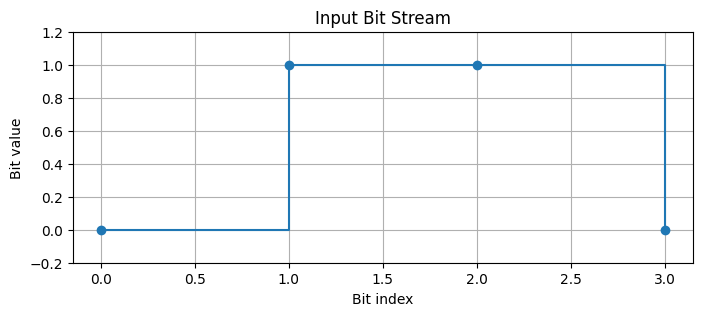

Input bits: 0110

SIMULATING 2QAM


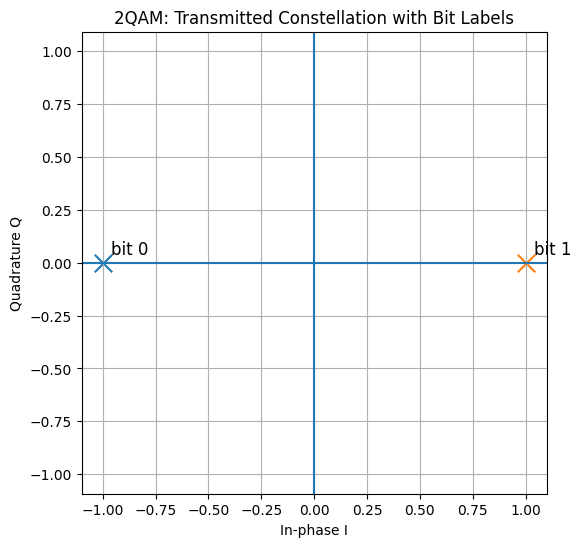

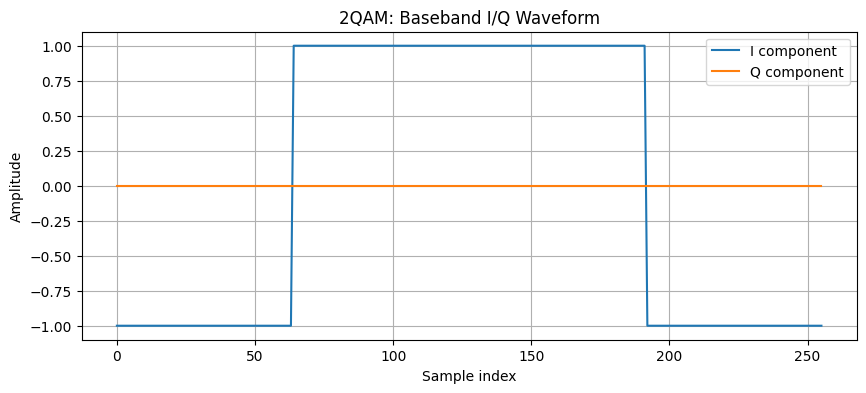

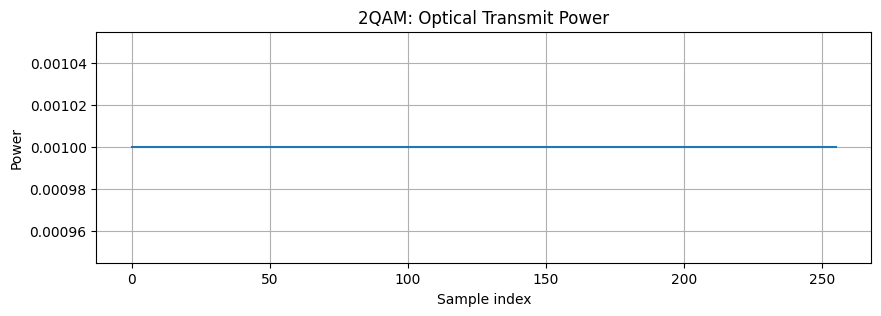

2QAM: Optical Transmit Power
Average power: 0.0009999999999999996
Peak power: 0.0009999999999999998
Minimum power: 0.0009999999999999998


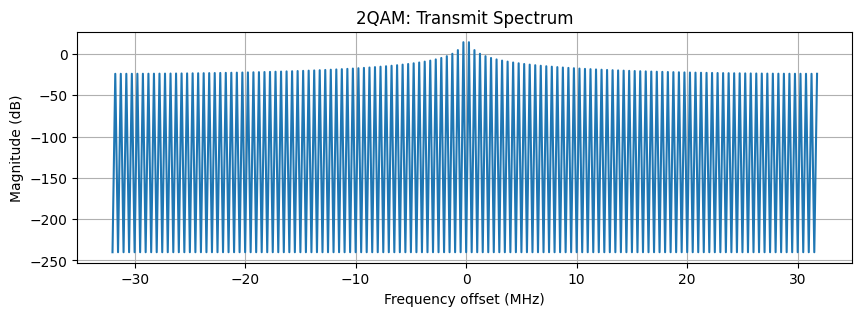

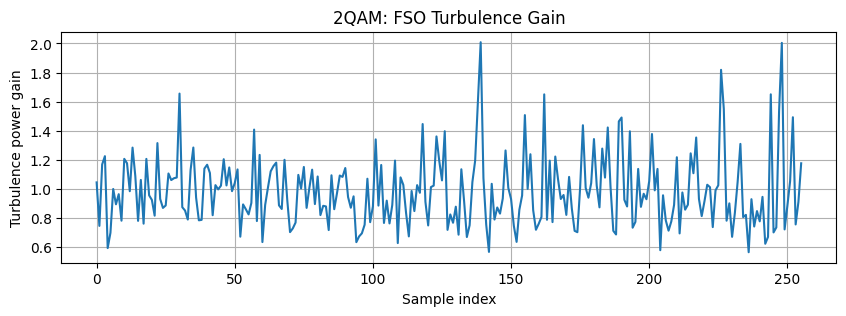

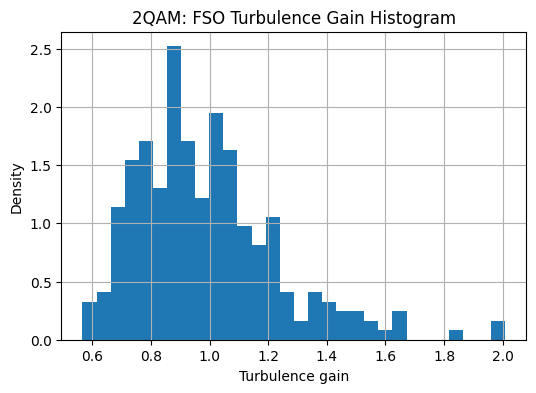

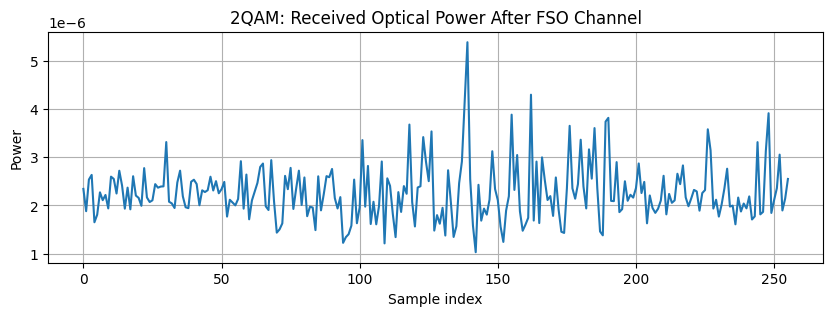

2QAM: Received Optical Power After FSO Channel
Average power: 2.2659843609165015e-06
Peak power: 5.385601643527304e-06
Minimum power: 1.0307325785688207e-06


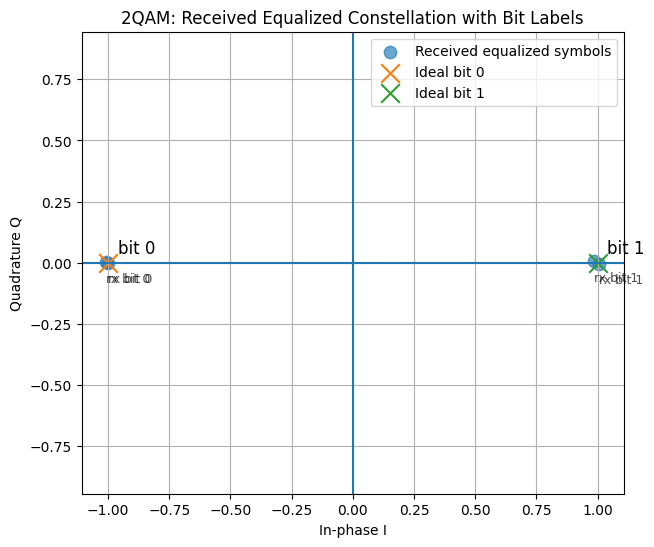


Channel parameters:
beam_radius_m: 1.01
eta_geometric: 0.002450740123517302
eta_atmospheric: 0.954992586021436
eta_pointing: 0.9801986733067553
mean_turbulence_gain: 0.9865345845314109
deterministic_gain: 0.002294094857945297
deterministic_loss_db: 26.393886285313126
atmospheric_loss_db: 0.2
pointing_loss_db: 0.08685889638065059
noise_power: 7.156879188901462e-09
rx_average_power_watts: 2.2659843609165015e-06

Receiver/equalizer:
Estimated complex channel gain h_hat: (0.001492472809549484-2.283333238636094e-06j)
Magnitude |h_hat|: 0.0014924745561835247
Phase angle(h_hat) rad: -0.0015298981948470003

Recovered bits:
TX bits: 0110
RX bits: 0110

Metrics:
bit_errors: 0
ber: 0.0
evm_rms: 0.010321969325122382
evm_percent: 1.0321969325122382
effective_snr_linear: 9385.877285962444
effective_snr_db: 39.724748718051195

SIMULATING 2PSK


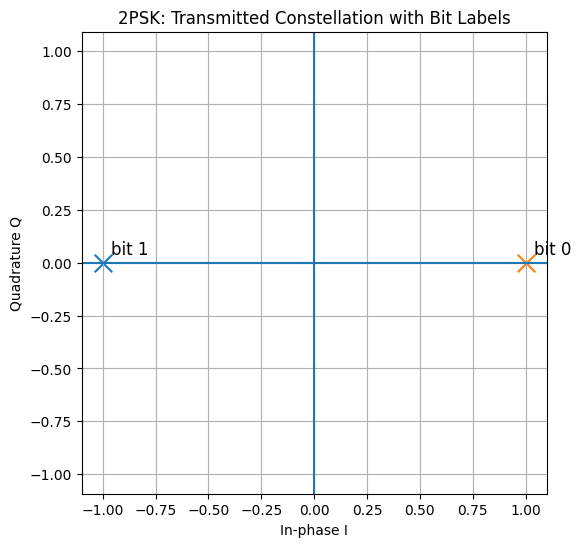

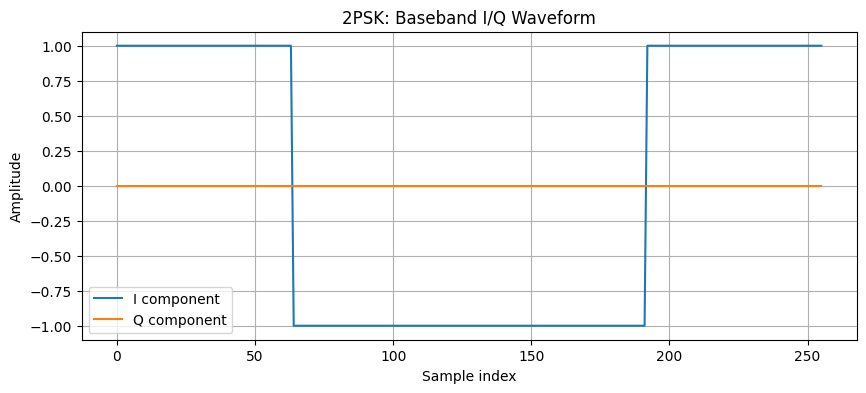

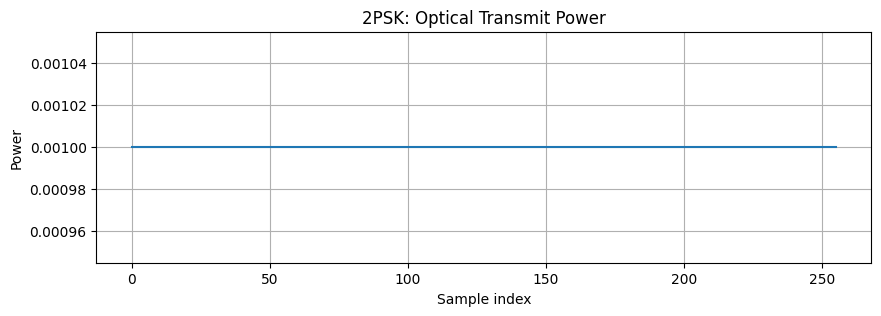

2PSK: Optical Transmit Power
Average power: 0.0009999999999999996
Peak power: 0.0009999999999999998
Minimum power: 0.0009999999999999998


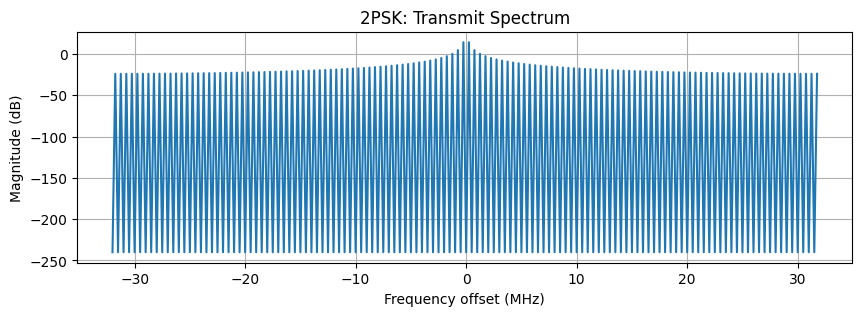

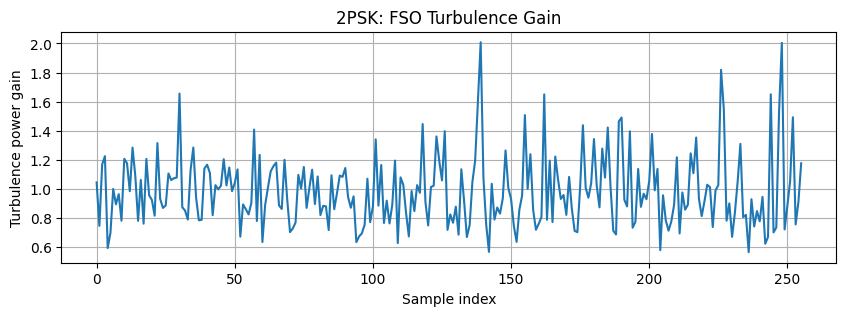

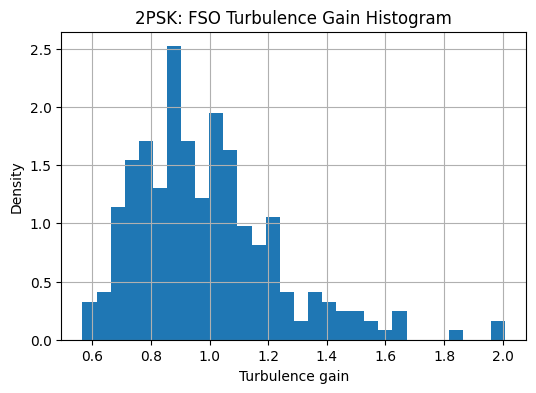

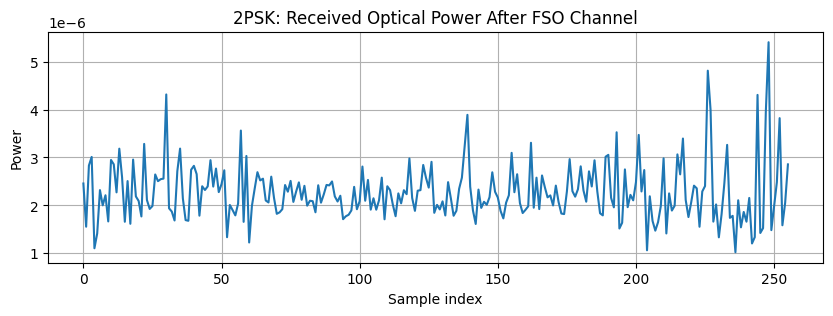

2PSK: Received Optical Power After FSO Channel
Average power: 2.2739411371367467e-06
Peak power: 5.403602096432159e-06
Minimum power: 1.0237663884097953e-06


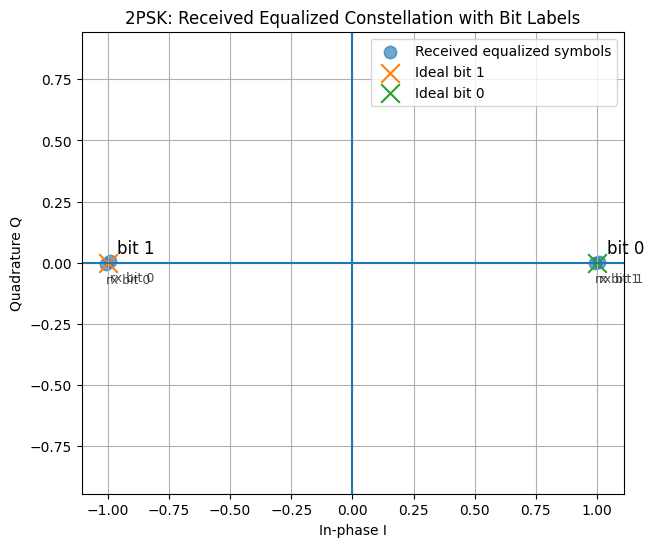


Channel parameters:
beam_radius_m: 1.01
eta_geometric: 0.002450740123517302
eta_atmospheric: 0.954992586021436
eta_pointing: 0.9801986733067553
mean_turbulence_gain: 0.9865345845314109
deterministic_gain: 0.002294094857945297
deterministic_loss_db: 26.393886285313126
atmospheric_loss_db: 0.2
pointing_loss_db: 0.08685889638065059
noise_power: 7.156879188901462e-09
rx_average_power_watts: 2.2739411371367467e-06

Receiver/equalizer:
Estimated complex channel gain h_hat: (0.001494751058139015+2.283333238636094e-06j)
Magnitude |h_hat|: 0.0014947528021108988
Phase angle(h_hat) rad: 0.0015275663798205055

Recovered bits:
TX bits: 0110
RX bits: 0110

Metrics:
bit_errors: 0
ber: 0.0
evm_rms: 0.008727580657875869
evm_percent: 0.8727580657875869
effective_snr_linear: 13128.413823011706
effective_snr_db: 41.18212257732569


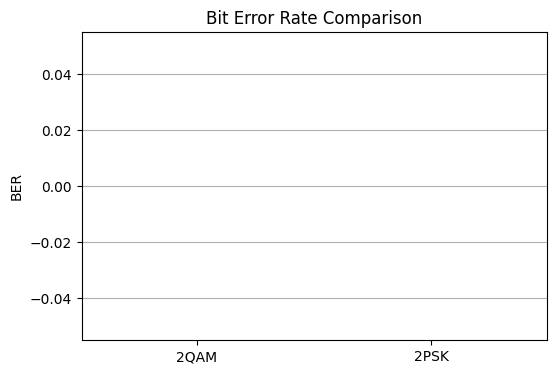

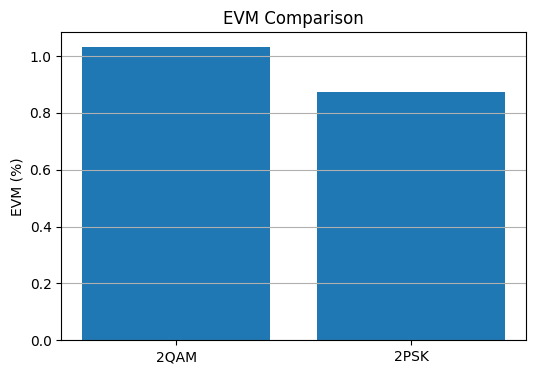

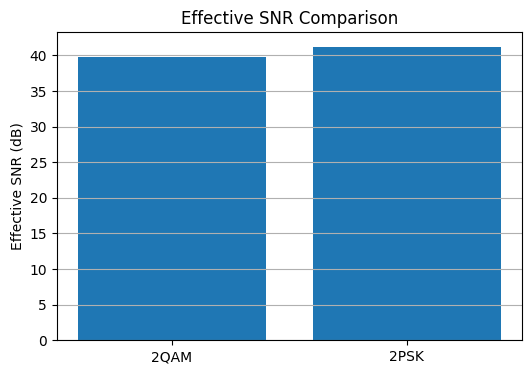


FINAL SYSTEM SUMMARY
Bits transmitted: 0110
Distance (km): 1.0
SNR input (dB): 25
Atmospheric attenuation (dB/km): 0.2
Scintillation sigma: 0.25
Pointing error (rad): 0.0001
Beam divergence (rad): 0.001

2QAM BER: 0.0
2PSK BER: 0.0
Simulation finished.
2QAM BER: 0.0
2PSK BER: 0.0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

results = simulate_2qam_2psk_fso_system(
    bits=np.array([0, 1, 1, 0]),
    samples_per_symbol=64,
    symbol_rate_baud=1e6,
    tx_power_watts=1e-3,
    distance_km=1.0,
    atmospheric_attenuation_db_per_km=0.2,
    scintillation_sigma=0.25,
    pointing_error_rad=0.1e-3,
    snr_db=25,
    seed=42,
    show_plots=True
)

print("Simulation finished.")
print("2QAM BER:", results["2QAM"]["metrics"]["ber"])
print("2PSK BER:", results["2PSK"]["metrics"]["ber"])